# **End-of-distribution imputation strategy On Skewed Distribued data** 

# --------------------------------------------------------------------------
## **Working With Right Skewed Data (+vely Skewed) without sklearn** 
# --------------------------------------------------------------------------

In [191]:
import pandas as pd
import numpy as np
import seaborn  as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [192]:
df = pd.read_csv('skewed_missing_dataset.csv')
df.head()

,Age,Fare,Income,Score,City
0,40.0,7.33,29247.62,95.55,Karachi
1,33.6,4.42,21450.23,93.41,Lahore
2,41.5,40.47,45407.03,83.19,NaN
3,50.2,49.03,92810.52,99.03,Karachi
4,32.7,1.28,NaN,96.45,Karachi


````
Tail points right → Right skewed (+)
Tail points left → Left skewed (−)
````

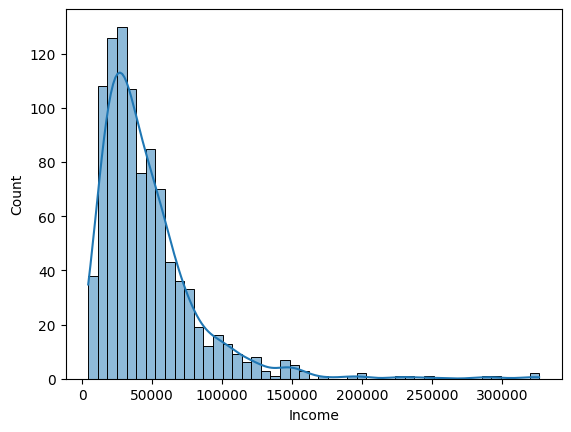

In [193]:
sns.histplot(df['Income'],kde=True)

plt.show()

In [194]:
x = df.drop(columns=['Fare'])
y = df['Fare']

In [195]:
x_train , x_test  , y_train , y_test = train_test_split(x,y , test_size=0.2 ,random_state=2)

In [196]:
Q1 = x_train['Income'].quantile(0.25)
Q3 = x_train['Income'].quantile(0.75)

In [197]:
IQR = Q3-Q1

In [198]:
x_train['Income_Q3']=x_train['Income'].fillna(Q3 + (1.5 * IQR))

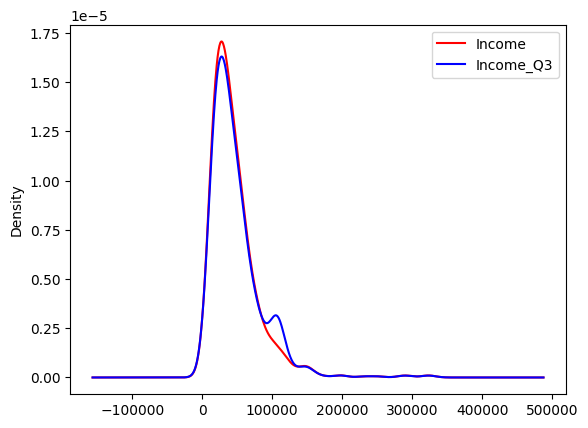

In [199]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Income'].plot(kind='kde' , color='red')
x_train['Income_Q3'].plot(kind='kde' , color='blue')

line , label = ax.get_legend_handles_labels()
ax.legend(line , label ,loc = 'best')
plt.show()

# --------------------------------------------------------------------------
## **Working With Right Skewed Data (+vely Skewed) with sklearn** 
# --------------------------------------------------------------------------

In [200]:
x_train , x_test  , y_train , y_test = train_test_split(x,y , test_size=0.2 ,random_state=2)

In [201]:
Q1 = x_train['Income'].quantile(0.25)
Q3 = x_train['Income'].quantile(0.75)
IQR = Q3-Q1

In [202]:
impute = SimpleImputer(strategy='constant' , fill_value=(Q3 + 1.5 * IQR)) #Because DAta is Right Skewed

In [203]:
trf1 = ColumnTransformer([
    ('Right_skewed' , impute , ['Income']) 
], remainder='passthrough')

In [204]:
x_train_trf = trf1.fit_transform(x_train)

In [205]:
x_train_trf1 = pd.DataFrame(x_train_trf, columns = trf1.get_feature_names_out())

In [206]:
x_train_trf1

,Right_skewed__Income,remainder__Age,remainder__Score,remainder__City
0,44350.88,43.3,81.12,Quetta
1,23457.8,35.8,88.32,Islamabad
2,15269.86,52.5,96.01,Islamabad
3,107787.0,22.5,77.27,Lahore
4,60328.93,38.6,83.73,Lahore
...,...,...,...,...
795,49397.29,28.5,94.12,Karachi
796,32561.02,36.8,94.79,Quetta
797,50202.19,26.4,93.29,Lahore
798,51452.8,35.5,95.62,Peshawar


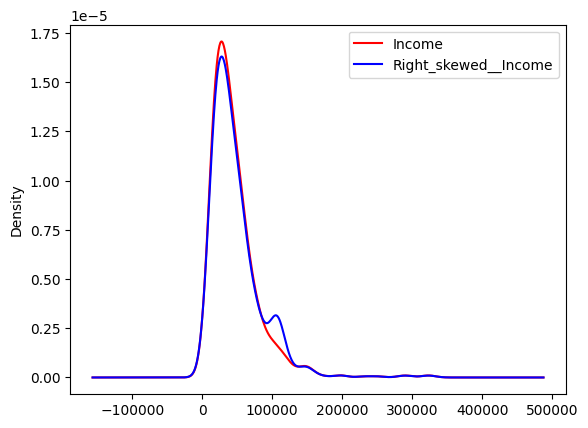

In [207]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Income'].plot(kind='kde' , color='red')
x_train_trf1['Right_skewed__Income'].plot(kind='kde' , color='blue')

line , label = ax.get_legend_handles_labels()
ax.legend(line , label ,loc = 'best')
plt.show()

# --------------------------------------------------------------------------
## **Working With Left Skewed Data (-vely Skewed) without sklearn** 
# --------------------------------------------------------------------------

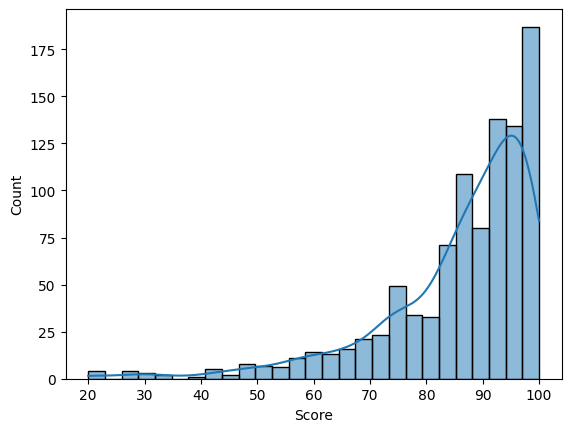

In [208]:
sns.histplot(df['Score'],kde=True)

plt.show()

In [209]:
x_train , x_test  , y_train , y_test = train_test_split(x,y , test_size=0.2 ,random_state=2)

In [210]:
Q1 = x_train['Score'].quantile(0.25)
Q3 = x_train['Score'].quantile(0.75)
IQR = Q3-Q1

In [211]:
x_train['Score_Q1']=x_train['Score'].fillna(Q1 - (1.5 * IQR))

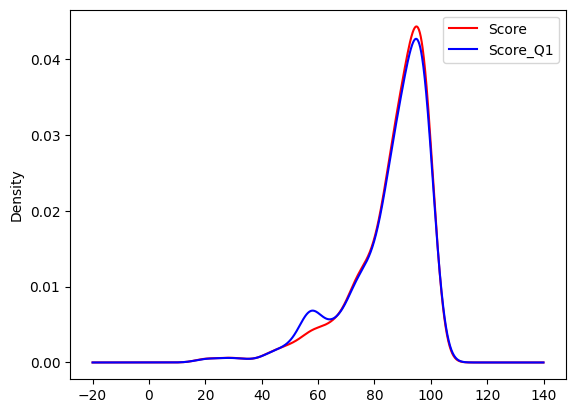

In [212]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Score'].plot(kind='kde' , color='red')
x_train['Score_Q1'].plot(kind='kde' , color='blue')

line , label = ax.get_legend_handles_labels()
ax.legend(line , label ,loc = 'best')
plt.show()

# --------------------------------------------------------------------------
## **Working With Left Skewed Data (-vely Skewed) with sklearn**     
( Q1 - 1.5*IQR )
# --------------------------------------------------------------------------

In [213]:
x_train , x_test  , y_train , y_test = train_test_split(x,y , test_size=0.2 ,random_state=2)
Q1 = x_train['Score'].quantile(0.25)
Q3 = x_train['Score'].quantile(0.75)
IQR = Q3-Q1


In [214]:
imputer = SimpleImputer(strategy='constant' , fill_value=(Q1 - 1.5 * IQR)) #Because DAta is left Skewed

In [215]:
trf2 = ColumnTransformer([
    ('Left_skewed' , imputer , ['Score']) 
], remainder='passthrough')

In [216]:
x_train_trf2 = trf2.fit_transform(x_train)

In [217]:
x_train_trf2 = pd.DataFrame(x_train_trf2, columns = trf2.get_feature_names_out())

In [218]:
x_train_trf2

,Left_skewed__Score,remainder__Age,remainder__Income,remainder__City
0,81.12,43.3,44350.88,Quetta
1,88.32,35.8,23457.8,Islamabad
2,96.01,52.5,15269.86,Islamabad
3,77.27,22.5,107787.0,Lahore
4,83.73,38.6,60328.93,Lahore
...,...,...,...,...
795,94.12,28.5,49397.29,Karachi
796,94.79,36.8,32561.02,Quetta
797,93.29,26.4,50202.19,Lahore
798,95.62,35.5,51452.8,Peshawar


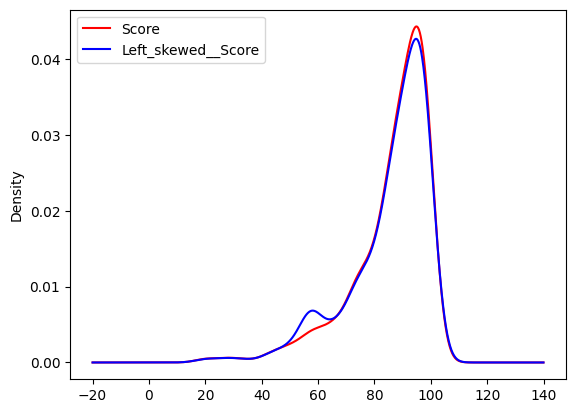

In [223]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Score'].plot(kind='kde' , color='red')
x_train_trf2['Left_skewed__Score'].plot(kind='kde' , color='blue')

line , label = ax.get_legend_handles_labels()
ax.legend(line , label ,loc = 'best')
plt.show()